In [1]:
import pandas as pd
import numpy as np
import joblib
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures, RobustScaler
from sklearn.metrics import classification_report, accuracy_score, mean_squared_error, r2_score, f1_score
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
from tensorflow.keras.regularizers import l2

keras.utils.set_random_seed(42)

## Train model neural network from cleaned_realistic_ocean_climate.csv

In [2]:
df_roc = pd.read_csv("../data/cleaned_realistic_ocean_climate.csv")
df_roc['Abs_Latitude'] = df_roc['Latitude'].abs()
df_roc['SST_pH_Stress'] = df_roc['SST (°C)'] / df_roc['pH Level']

X_roc = df_roc.drop(columns=["Bleaching Severity"])
y_roc = df_roc["Bleaching Severity"].replace({2: 1})

In [3]:
df_roc.shape

(500, 7)

In [4]:
df_roc.head()

,Latitude,Longitude,SST (°C),pH Level,Bleaching Severity,Abs_Latitude,SST_pH_Stress
0,20.0248,38.4931,29.47,8.107,0,20.0248,3.635130
1,-18.2988,147.7782,29.65,8.004,2,18.2988,3.704398
2,14.9768,-75.0233,28.86,7.947,2,14.9768,3.631559
3,-18.3152,147.6486,28.97,7.995,1,18.3152,3.623515
4,-0.8805,-90.9769,28.60,7.977,0,0.8805,3.585308


In [5]:
X_temp_roc, X_test_roc, y_temp_roc, y_test_roc = train_test_split( X_roc, y_roc, test_size=0.2, random_state=42, stratify=y_roc )
X_train_roc, X_val_roc, y_train_roc, y_val_roc = train_test_split( X_temp_roc, y_temp_roc, test_size=0.25, random_state=42, stratify=y_temp_roc )

scaler_roc = MinMaxScaler()
X_train_roc_sc = scaler_roc.fit_transform(X_train_roc)
X_val_roc_sc   = scaler_roc.transform(X_val_roc)
X_test_roc_sc  = scaler_roc.transform(X_test_roc)
weights = class_weight.compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train_roc), y=y_train_roc
)
cw = dict(enumerate(weights))

ann_roc = keras.Sequential([
    layers.Input(shape=(X_train_roc_sc.shape[1],)),
    # ใช้ swish และใส่ L2 เพื่อป้องกัน Overfitting
    layers.Dense(64, activation="swish", kernel_regularizer=l2(0.005)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation="swish", kernel_regularizer=l2(0.005)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(16, activation="swish", kernel_regularizer=l2(0.005)),
    layers.Dense(1, activation="sigmoid")
], name="ANN_ROC_Upgraded")

ann_roc.summary()

Model: "ANN_ROC_Upgraded"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 192 (768.00 B)

In [6]:
optimizer = keras.optimizers.Adam(learning_rate=0.001)
ann_roc.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
callbacks_roc = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5)
]

history_roc = ann_roc.fit(
    X_train_roc_sc, y_train_roc,
    epochs=200, batch_size=32,
    validation_data=(X_val_roc_sc, y_val_roc),
    callbacks=callbacks_roc,
    class_weight=cw,
    verbose=1
)

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.5200 - loss: 1.1231 - val_accuracy: 0.5600 - val_loss: 1.0549 - learning_rate: 0.0010
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5100 - loss: 1.1120 - val_accuracy: 0.5900 - val_loss: 1.0499 - learning_rate: 0.0010
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5600 - loss: 1.0854 - val_accuracy: 0.5800 - val_loss: 1.0453 - learning_rate: 0.0010
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5000 - loss: 1.0846 - val_accuracy: 0.5500 - val_loss: 1.0408 - learning_rate: 0.0010
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5133 - loss: 1.0967 - val_accuracy: 0.4900 - val_loss: 1.0369 - learning_rate: 0.0010
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5433 - loss: 1.0509 - val_accuracy: 0.4900 - val_loss: 1.0327 - learning_rate: 0.0010
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5300 - loss: 1.0581 - 

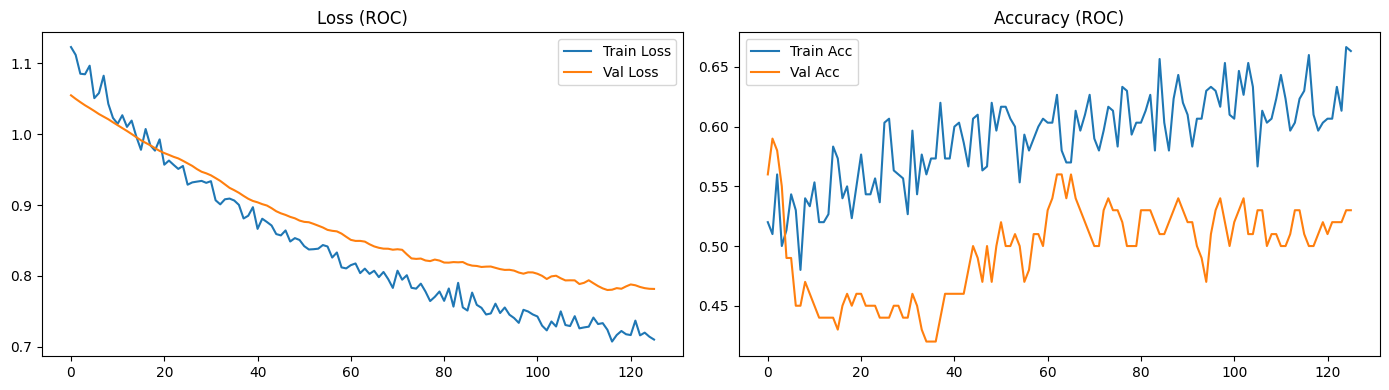

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_roc.history["loss"],         label="Train Loss")
axes[0].plot(history_roc.history["val_loss"],     label="Val Loss")
axes[0].set_title("Loss (ROC)"); axes[0].legend()
axes[1].plot(history_roc.history["accuracy"],     label="Train Acc")
axes[1].plot(history_roc.history["val_accuracy"], label="Val Acc")
axes[1].set_title("Accuracy (ROC)"); axes[1].legend()
plt.tight_layout()
plt.savefig("../models/ann_roc_training_curves.png", dpi=150)
plt.show()

In [8]:
y_prob_val = ann_roc.predict(X_val_roc_sc)
best_thresh, best_f1 = 0.5, 0
for thresh in np.arange(0.3, 0.7, 0.01):
    f1 = f1_score(y_val_roc, (y_prob_val > thresh).astype(int), average="macro")
    if f1 > best_f1:
        best_f1, best_thresh = f1, thresh

y_prob_roc = ann_roc.predict(X_test_roc_sc)
y_pred = (y_prob_roc > best_thresh).astype(int)
acc = accuracy_score(y_test_roc, y_pred)

print(f"\nBest Threshold : {best_thresh:.2f}")
print(f"Test Accuracy  : {acc*100:.2f}%")
print(f"F1 Macro       : {best_f1:.4f}")
print(classification_report(y_test_roc, y_pred, target_names=["Low", "Severe"]))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

Best Threshold : 0.53
Test Accuracy  : 46.00%
F1 Macro       : 0.5305
              precision    recall  f1-score   support

         Low       0.51      0.66      0.58        56
      Severe       0.32      0.20      0.25        44

    accuracy                           0.46       100
   macro avg       0.42      0.43      0.41       100
weighted avg       0.43      0.46      0.43       100



In [9]:
joblib.dump(scaler_roc, "../models/scaler_ROC.pkl")
ann_roc.save("../models/neural_network_ROC.keras")

## Train model neural network from cleaned_global_bleaching_events.csv

In [10]:
df_gbe = pd.read_csv("../data/cleaned_global_bleaching_events.csv")

x_gbe = df_gbe.drop(columns=["Percent_Bleaching"])
y_gbe = df_gbe["Percent_Bleaching"]

print(f"Original features: {list(x_gbe.columns)}")
print(f"Shape: {x_gbe.shape}")

Original features: ['Depth_m', 'Distance_to_Shore', 'Turbidity', 'Windspeed', 'Cyclone_Frequency', 'Temperature_Maximum', 'SSTA', 'SSTA_Maximum', 'SSTA_DHW', 'TSA_DHW']
Shape: (23131, 10)


In [11]:
df_gbe.shape

(23131, 11)

In [12]:
df_gbe.head()

,Depth_m,Distance_to_Shore,Turbidity,Windspeed,Cyclone_Frequency,Temperature_Maximum,SSTA,SSTA_Maximum,SSTA_DHW,TSA_DHW,Percent_Bleaching
0,10.00,8519.23,0.0287,8.0,49.90,304.69,-0.46,2.24,0.00,0.00,50.2
1,14.00,1431.62,0.0262,2.0,51.20,305.01,1.29,3.10,0.26,0.26,50.7
2,7.00,182.33,0.0429,8.0,61.52,304.14,0.04,2.83,0.00,0.00,50.9
3,9.02,313.13,0.0424,3.0,65.39,304.07,-0.07,2.47,0.00,0.00,50.9
4,12.50,792.00,0.0424,3.0,65.39,303.76,0.00,2.30,0.00,0.00,50.9


In [13]:
X_temp_gbe, X_test_gbe, y_temp_gbe, y_test_gbe = train_test_split( x_gbe, y_gbe, test_size=0.2, random_state=42 )
X_train_gbe, X_val_gbe, y_train_gbe, y_val_gbe = train_test_split( X_temp_gbe, y_temp_gbe, test_size=0.25, random_state=42 )

In [14]:
scaler_gbe = RobustScaler()   # robust ต่อ outliers มากกว่า MinMaxScaler
X_train_gbe_sc = scaler_gbe.fit_transform(X_train_gbe)
X_val_gbe_sc   = scaler_gbe.transform(X_val_gbe)
X_test_gbe_sc  = scaler_gbe.transform(X_test_gbe)

poly_gbe = PolynomialFeatures(degree=2, include_bias=False)
X_train_gbe_sc = poly_gbe.fit_transform(X_train_gbe_sc)
X_val_gbe_sc   = poly_gbe.transform(X_val_gbe_sc)
X_test_gbe_sc  = poly_gbe.transform(X_test_gbe_sc)

print(f"Features after PolynomialFeatures: {X_train_gbe_sc.shape[1]}")

Features after PolynomialFeatures: 65


In [15]:
joblib.dump(scaler_gbe, "../models/scaler_GBE.pkl")
joblib.dump(poly_gbe,   "../models/poly_GBE.pkl")

['../models/poly_GBE.pkl']

## Two-Stage Model (GBE)
แบ่งปัญหาออก 2 ขั้น:
- **Stage 1** — Classifier: "bleach หรือไม่?" (0 vs >0)
- **Stage 2** — Regressor: "bleach เท่าไหร่?" (เฉพาะ rows ที่ > 0)
- **Final** — ใช้ Hard Threshold จาก val set ตัดสินใจ

In [16]:
# ---- Stage 1: Binary Classifier (bleach หรือไม่?) ----
y_clf_train = (y_train_gbe.values > 0).astype(int)
y_clf_val   = (y_val_gbe.values   > 0).astype(int)

cw_clf = dict(enumerate(class_weight.compute_class_weight(
    class_weight="balanced", classes=np.unique(y_clf_train), y=y_clf_train
)))

callbacks_gbe = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5)
]

clf_gbe = keras.Sequential([
    layers.Input(shape=(X_train_gbe_sc.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
], name="Stage1_Classifier")

clf_gbe.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

clf_gbe.fit(
    X_train_gbe_sc, y_clf_train,
    epochs=100, batch_size=32,
    validation_data=(X_val_gbe_sc, y_clf_val),
    class_weight=cw_clf,
    callbacks=callbacks_gbe,
    verbose=1
)

Epoch 1/100
434/434 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6355 - loss: 0.6347 - val_accuracy: 0.6781 - val_loss: 0.5996 - learning_rate: 0.0010
Epoch 2/100
434/434 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6812 - loss: 0.5857 - val_accuracy: 0.6907 - val_loss: 0.5791 - learning_rate: 0.0010
Epoch 3/100
434/434 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6939 - loss: 0.5664 - val_accuracy: 0.7047 - val_loss: 0.5634 - learning_rate: 0.0010
Epoch 4/100
434/434 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7038 - loss: 0.5540 - val_accuracy: 0.7084 - val_loss: 0.5557 - learning_rate: 0.0010
Epoch 5/100
434/434 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7108 - loss: 0.5430 - val_accuracy: 0.7090 - val_loss: 0.5521 - learning_rate: 0.0010
Epoch 6/100
434/434 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7210 - loss: 0.5338 - val_accuracy: 0.7142 - val_loss: 0.5484 - learning_rate: 0.0010
Epoch 7/100
434/434 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7283 - loss: 0.

In [17]:
# ---- Stage 2: Regressor (เฉพาะ rows ที่ bleach > 0) ----
mask_train = y_train_gbe.values > 0
mask_val   = y_val_gbe.values   > 0

X_reg_train = X_train_gbe_sc[mask_train]
y_reg_train = np.sqrt(y_train_gbe.values[mask_train])   # sqrt แทน log1p (skew=1.59 ใช้ sqrt ได้ดีกว่า)
X_reg_val   = X_val_gbe_sc[mask_val]
y_reg_val   = np.sqrt(y_val_gbe.values[mask_val])

# Sample weight: ให้ high bleaching (>50%) มี weight มากกว่า
raw_y  = y_train_gbe.values[mask_train]
sw_reg = np.where(raw_y > 50, 3.0, np.where(raw_y > 20, 2.0, 1.0))

print(f"Reg train size: {X_reg_train.shape[0]}  ({X_reg_train.shape[0]/X_train_gbe_sc.shape[0]*100:.1f}% of train)")

callbacks_reg = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8)
]

reg_gbe = keras.Sequential([
    layers.Input(shape=(X_train_gbe_sc.shape[1],)),
    layers.Dense(128, activation="swish"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(64, activation="swish"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation="swish"),
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    layers.Dense(16, activation="swish"),
    layers.Dense(1, activation="linear")
], name="Stage2_Regressor")

reg_gbe.compile(optimizer="adam", loss="huber", metrics=["mae"])

reg_gbe.fit(
    X_reg_train, y_reg_train,
    epochs=200, batch_size=32,
    validation_data=(X_reg_val, y_reg_val),
    sample_weight=sw_reg,
    callbacks=callbacks_reg,
    verbose=1
)

Reg train size: 8438  (60.8% of train)
Epoch 1/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.3434 - mae: 2.2924 - val_loss: 1.5147 - val_mae: 1.9656 - learning_rate: 0.0010
Epoch 2/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.5903 - mae: 2.1150 - val_loss: 1.6134 - val_mae: 2.0613 - learning_rate: 0.0010
Epoch 3/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.4586 - mae: 2.0426 - val_loss: 1.5917 - val_mae: 2.0388 - learning_rate: 0.0010
Epoch 4/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.4132 - mae: 2.0240 - val_loss: 1.5587 - val_mae: 2.0007 - learning_rate: 0.0010
Epoch 5/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.3328 - mae: 1.9712 - val_loss: 1.5267 - val_mae: 1.9730 - learning_rate: 0.0010
Epoch 6/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.2897 - mae: 1.9413 - val_loss: 1.4776 - val_mae: 1.9202 - learning_rate: 0.0010
Epoch 7/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.2429 - mae: 1.9195 - val_loss: 1.4864 - 

In [18]:
# ---- Final Prediction: Hard Threshold ----
prob_val     = clf_gbe.predict(X_val_gbe_sc).flatten()
pred_amt_val = np.clip(np.square(reg_gbe.predict(X_val_gbe_sc).flatten()), 0, 100)

# หา best threshold บน val set
best_thresh_ts, best_r2_val = 0.5, -np.inf
for thresh in np.linspace(0.2, 0.8, 61):
    y_tmp  = np.where(prob_val > thresh, pred_amt_val, 0)
    r2_tmp = r2_score(y_val_gbe, y_tmp)
    if r2_tmp > best_r2_val:
        best_r2_val, best_thresh_ts = r2_tmp, thresh

print(f"Best threshold (from val): {best_thresh_ts:.2f}  (val R²={best_r2_val:.4f})")

# Predict บน test set ด้วย best threshold
prob_bleach = clf_gbe.predict(X_test_gbe_sc).flatten()
pred_amount = np.clip(np.square(reg_gbe.predict(X_test_gbe_sc).flatten()), 0, 100)

y_pred_two_stage = np.where(prob_bleach > best_thresh_ts, pred_amount, 0)

rmse_ts = np.sqrt(mean_squared_error(y_test_gbe, y_pred_two_stage))
r2_ts   = r2_score(y_test_gbe, y_pred_two_stage)

print(f"\nRMSE : {rmse_ts:.4f}")
print(f"R²   : {r2_ts:.4f}")

145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1000us/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Best threshold (from val): 0.48  (val R²=0.2919)
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 759us/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

RMSE : 19.7628
R²   : 0.2306


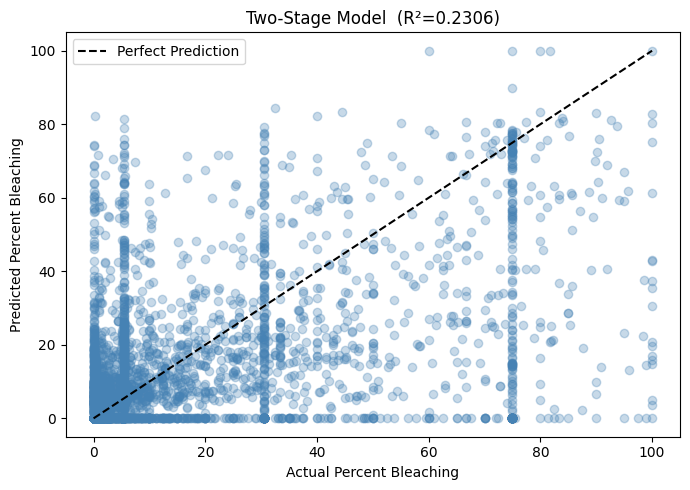

In [19]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_gbe, y_pred_two_stage, alpha=0.3, color="steelblue")
plt.plot([0, 100], [0, 100], "k--", label="Perfect Prediction")
plt.xlabel("Actual Percent Bleaching")
plt.ylabel("Predicted Percent Bleaching")
plt.title(f"Two-Stage Model  (R²={r2_ts:.4f})")
plt.legend()
plt.tight_layout()
plt.savefig("../models/ann_gbe_actual_vs_predicted.png", dpi=150)
plt.show()

In [20]:
# ---- บันทึก Two-Stage Models ----
clf_gbe.save("../models/stage1_classifier_GBE.keras")
reg_gbe.save("../models/stage2_regressor_GBE.keras")
joblib.dump(best_thresh_ts, "../models/threshold_GBE.pkl")
print(f"Saved: stage1, stage2, threshold={best_thresh_ts:.2f}")

Saved: stage1, stage2, threshold=0.48
